# ColBERT Late Interaction — Multi-Vector MaxSim Retrieval

## What problem does this solve?

Single-vector retrieval loses information. A 1024-dim vector cannot remember every named entity, every relationship, every nuanced phrase. When you embed a 400-word chunk into one vector, you average it. Some signal survives, some does not.
ColBERT — Contextualised Late Interaction over BERT, 2020 — keeps every token's embedding. At search time, for each query token, find its maximum cosine over chunk tokens, sum those maxes. The chunk score is the sum of per-query-token MaxSims. State-of-the-art recall on BEIR; ColBERT v2 cut storage by 80x with quantisation. By 2026 every major vector store (Qdrant, Weaviate, Vespa, LanceDB) supports multi-vector retrieval natively.

## Where it came from

ColBERT was introduced by Khattab and Zaharia at Stanford in 2020. The original paper showed near-cross-encoder quality at bi-encoder speed. ColBERT v2 (2022) added quantisation, residual compression, and approximate MaxSim that brought storage costs into the range where multi-vector indexes are practical.
By 2024 ColBERT-style late interaction had become the dominant pattern for high-recall retrieval, with the multimodal variant (ColPali — Recipe 35) extending it to vision-language models. The 2026 wave of multi-vector-native vector stores (Qdrant 1.10+, Weaviate v1.27+) made it trivial to deploy without DIY token-level indexing.

## Where it fits in the RAG landscape

Three levels of retrieval expressivity:

- **Single-vector dense (Recipe 2)** — one vector per chunk. Cheapest, fastest, lowest ceiling.
- **Multi-vector late interaction (this recipe)** — per-token vectors, MaxSim aggregation. Higher recall, ~30x storage, comparable inference latency.
- **Cross-encoder reranker (Recipe 22)** — joint scoring at query time. Highest quality, slowest, used as a reranker over a shortlist.

Production systems usually combine: shortlist with single-vector dense, rerank with ColBERT MaxSim or a cross-encoder. The cookbook shows the pure ColBERT path here so the technique is visible end to end; recipe 22 shows the shortlist+rerank composition.

## When to use it (and when not to)

Use ColBERT when retrieval quality matters more than storage cost. Search, e-discovery, anything where a 5–10 percent recall lift translates directly to business value. Multi-vector storage at 30x the size of a single-vector index is a few extra dollars at gigabyte scale and a real budget conversation at terabyte scale.
Skip it when storage cost dominates and a cheaper reranker is available. A cross-encoder rerank over single-vector dense is often almost as good for half the storage budget.
Skip it when your corpus is small. With under 10k chunks, single-vector dense is already accurate enough that ColBERT's marginal lift may not pay for the engineering complexity.

## The intuition

Three intuitions:

**MaxSim is per-token best-matching.** For each query token, you find the chunk token that matches it best. The chunk score is the sum of those best matches. The chunk "wins" if it has *some* token that matches each query token well, not if its average vector is similar.

**Late interaction means "compute interactions late, not early".** A cross-encoder interacts query and chunk inside the model. A bi-encoder interacts not at all — it just produces independent vectors. Late interaction is the middle: independent token vectors, interacted via MaxSim at search time.

**Token-level precision is what wins on rare entities.** A query mentioning "selective scan" should retrieve chunks that contain the words "selective" and "scan" near each other. Single-vector embedders average those away; ColBERT keeps the token signals separate and compares them individually.

## Architecture

```mermaid
flowchart TB
  Q[Query] --> QT[Per-query-token<br/>embeddings]
  C[Chunks] --> CT[Per-chunk-token<br/>embeddings]
  CT --> S[(Multi-vector<br/>index)]
  QT --> MS[For each query token<br/>find max sim over chunk tokens]
  S --> MS
  MS --> SUM[Sum MaxSims<br/>= chunk score]
  SUM --> R[Ranked chunks]
```

## References

- 📄 [ColBERT — Efficient and Effective Passage Search (Khattab and Zaharia, 2020)](https://arxiv.org/abs/2004.12832) — The original paper.
- 📄 [ColBERTv2 — Compressed Late Interaction (Santhanam et al., 2022)](https://arxiv.org/abs/2112.01488) — The version that made storage costs practical.
- 💻 [ColBERT v2 reference repository](https://github.com/stanford-futuredata/ColBERT) — Stanford's canonical implementation.
- 📚 [Qdrant Multi-Vector documentation](https://qdrant.tech/documentation/concepts/vectors/#multivectors) — Native multi-vector retrieval in our default vector store.
- 📚 [fastembed Late-Interaction Embedding](https://qdrant.github.io/fastembed/examples/Supported_Models/) — The ColBERTv2 loader used in this recipe.
- 💻 [BEIR Benchmark](https://github.com/beir-cellar/beir) — The standard recall benchmark on which ColBERT's lift was measured.

## Setup

Pick a provider via the `PROVIDER` env var; everything below is provider-agnostic. The default is Nebius. Tracing is off by default in published notebooks so the outputs are clean — flip `COOKBOOK_TRACING=phoenix` to send spans to a local Phoenix UI.

In [1]:
import os
os.environ.setdefault('PROVIDER', 'nebius')
os.environ.setdefault('COOKBOOK_TRACING', 'off')

from cookbook.providers import LLMClient
from cookbook.tracing import init_tracing

client = LLMClient()
print(f'Provider: {client.provider}  |  Chat model: {client.chat_model}')
print(init_tracing())

Provider: nebius  |  Chat model: meta-llama/Llama-3.3-70B-Instruct
Tracing disabled.


## Build the Pipeline, Step by Step

### Step 1 — Load the corpus and chunk it

We use a small slice of the Mamba paper. ColBERT's storage scales as `n_chunks * tokens_per_chunk * dim`, so notebook-scale demonstrations need small chunk counts. The technique generalises directly; only the indexing cost grows.

In [2]:
from cookbook.corpora import load_arxiv_mamba
from cookbook.chunkers import sentence_window

docs = list(load_arxiv_mamba())[:6]
chunks = sentence_window(docs, sentences_per_chunk=4, overlap=1)
print(f'Working with {len(chunks)} chunks.')

Working with 81 chunks.


### Step 2 — Load the late-interaction embedder

We use `fastembed`'s ColBERT v2 — small, fast, CPU-runnable. The model emits token-level embeddings; `embed(text)` returns one vector per token rather than one vector per text.

In [3]:
from fastembed import LateInteractionTextEmbedding

encoder = LateInteractionTextEmbedding('colbert-ir/colbertv2.0')
print('Loaded ColBERT v2.')
sample = list(encoder.embed(['selective scan in state-space models']))[0]
print(f'Sample produced {len(sample)} token vectors of dim {len(sample[0])}.')

C:\Users\faree\Desktop\rag\rag-cookbook-2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded ColBERT v2.
Sample produced 9 token vectors of dim 128.


### Step 3 — Index per-chunk token embeddings

Compute token embeddings for every chunk and keep them in memory. For 100+ chunks this is the slow step; once cached it is reused freely.

In [4]:
import numpy as np

chunk_token_arrays = []
for v in encoder.embed([c.text for c in chunks]):
    arr = np.asarray(v, dtype=np.float32)
    arr /= np.linalg.norm(arr, axis=1, keepdims=True).clip(min=1e-9)
    chunk_token_arrays.append(arr)
print(f'Indexed {len(chunk_token_arrays)} chunks with token-level vectors.')
print(f'First chunk: {chunk_token_arrays[0].shape[0]} token vectors, dim={chunk_token_arrays[0].shape[1]}.')

Indexed 81 chunks with token-level vectors.
First chunk: 284 token vectors, dim=128.


### Step 4 — Implement MaxSim

For a query, embed it (per-token), then for each query token find its best cosine over all token vectors of a chunk, sum those, that is the chunk score. Iterate over chunks. This is the search loop — slow in pure Python, fast in C inside Qdrant's multi-vector index.

In [5]:
def maxsim(query_tokens: np.ndarray, chunk_token_lists) -> list[float]:
    scores = []
    for tlist in chunk_token_lists:
        sim = query_tokens @ tlist.T
        scores.append(float(sim.max(axis=1).sum()))
    return scores

q = 'What is selective scan and why does it matter?'
q_tokens = np.asarray(list(encoder.query_embed([q]))[0], dtype=np.float32)
q_tokens /= np.linalg.norm(q_tokens, axis=1, keepdims=True).clip(min=1e-9)
scores = maxsim(q_tokens, chunk_token_arrays)
ranked = sorted(zip(scores, chunks), key=lambda x: x[0], reverse=True)[:5]
for s, c in ranked:
    print(f'  score={s:6.2f}  {c.text[:160]}')

  score= 12.87  The primary challenges stem from computational complexity and
the ability to capture long-range dependencies within the sequence. Recently, a state space model 
  score= 12.24  Uncovering Selective State Space Model’s Capabilities in Lifelong Sequential Recommendation
Conference acronym ’XX, June 03–05, 2018, Woodstock, NY
(a)
(b)
Figu
  score= 11.26  Uncovering Selective State Space Model’s Capabilities in Lifelong Sequential Recommendation
Conference acronym ’XX, June 03–05, 2018, Woodstock, NY
interesting 
  score= 10.88  More specifically, we leverage the Mamba block to
model lifelong user sequences selectively. We conduct extensive ex-
periments to evaluate the performance of r
  score= 10.48  Uncovering Selective State Space Model’s Capabilities in Lifelong
Sequential Recommendation
Jiyuan Yang
jiyuan.yang@mail.sdu.edu.cn
Shandong University
Qingdao,


### Step 5 — Wrap as `answer_question`

Standard cookbook contract. Internally uses MaxSim retrieval; externally identical to every other recipe.

In [6]:
def colbert_search(query: str, top_k: int = 5):
    qt = np.asarray(list(encoder.query_embed([query]))[0], dtype=np.float32)
    qt /= np.linalg.norm(qt, axis=1, keepdims=True).clip(min=1e-9)
    s = maxsim(qt, chunk_token_arrays)
    return sorted(zip(s, chunks), key=lambda x: x[0], reverse=True)[:top_k]

def answer_question(question: str, k: int = 5) -> tuple[str, list[str]]:
    hits = colbert_search(question, top_k=k)
    contexts = [c.text for _, c in hits]
    answer = client.chat(
        'Use these passages.\n' + '\n\n'.join(contexts) + f'\nQ: {question}\nA:'
    )
    return answer, contexts

ans, _ = answer_question('What is selective scan?')
print(ans)

The passage does not mention "selective scan". However, it does mention a "selective mechanism" and a "selective state space" in the context of the Mamba model, which is a state space model featuring a selective mechanism for sequence modeling. 

If you're looking for information on what "selective state space" refers to in this context, it appears to be a component of the Mamba model that allows for efficient and effective modeling of long sequences by selectively capturing relevant information. However, the passage does not provide a detailed explanation of how this mechanism works. 

It's worth noting that the passage cites a paper by Albert Gu and Tri Dao (2023) titled "Mamba: Linear-time sequence modeling with selective state spaces", which may provide more information on the selective state space mechanism.


## Look Inside

### Inspect — per-token attention pattern

For a query, look at the per-query-token MaxSim contributions to the top-1 chunk. Each query token finds its best matching chunk token; summing those is the chunk's score. The shape of those contributions tells you which query tokens carried the chunk into the top-1.

In [7]:
q = 'selective scan in state-space models'
qt = np.asarray(list(encoder.query_embed([q]))[0], dtype=np.float32)
qt /= np.linalg.norm(qt, axis=1, keepdims=True).clip(min=1e-9)
scores = maxsim(qt, chunk_token_arrays)
best_chunk = int(np.argmax(scores))
sims = qt @ chunk_token_arrays[best_chunk].T
print(f'Best chunk index: {best_chunk}  total MaxSim: {scores[best_chunk]:.3f}')
print()
print('Per-query-token MaxSim contribution to the best chunk:')
for q_i in range(min(8, qt.shape[0])):
    contrib = float(sims[q_i].max())
    print(f'  q_token {q_i:2d}: max={contrib:.3f}')

Best chunk index: 23  total MaxSim: 22.829

Per-query-token MaxSim contribution to the best chunk:
  q_token  0: max=0.599
  q_token  1: max=0.869
  q_token  2: max=0.858
  q_token  3: max=0.318
  q_token  4: max=0.544
  q_token  5: max=0.807
  q_token  6: max=0.739
  q_token  7: max=0.884


### Inspect — storage comparison

How much bigger is the multi-vector index than the single-vector equivalent? Multiply per-chunk tokens by dim to get the per-chunk cost.

In [8]:
single_vec_dim = 1024  # Nebius default
single_vec_bytes = single_vec_dim * 4
multi_vec_bytes = sum(arr.size * 4 for arr in chunk_token_arrays) / len(chunk_token_arrays)
print(f'Single-vector per chunk: {single_vec_bytes:,} bytes')
print(f'Multi-vector  per chunk: {int(multi_vec_bytes):,} bytes')
print(f'Ratio: ~{int(multi_vec_bytes / single_vec_bytes)}x')

Single-vector per chunk: 4,096 bytes
Multi-vector  per chunk: 46,484 bytes
Ratio: ~11x


### Inspect — MaxSim score distribution

For one query, plot the score distribution across all chunks. The shape tells you whether ColBERT is confidently ranking (sharp peak) or uncertain (flat curve).

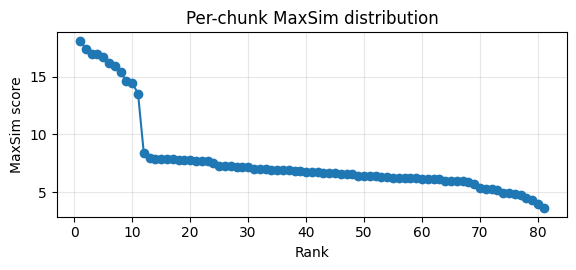

In [9]:
import matplotlib.pyplot as plt

q = 'selective scan'
qt = np.asarray(list(encoder.query_embed([q]))[0], dtype=np.float32)
qt /= np.linalg.norm(qt, axis=1, keepdims=True).clip(min=1e-9)
scores = sorted(maxsim(qt, chunk_token_arrays), reverse=True)
fig, ax = plt.subplots(figsize=(6, 2.8))
ax.plot(range(1, len(scores) + 1), scores, marker='o')
ax.set_xlabel('Rank')
ax.set_ylabel('MaxSim score')
ax.set_title('Per-chunk MaxSim distribution')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Inspect — does ColBERT change the top-1 on rare-term queries?

Single-vector dense embedders often miss queries with rare technical terms. ColBERT's per-token matching is supposed to catch them. Compare on a few such queries.

In [10]:
from cookbook.stores import QdrantBackend
dense_vectors = client.embed([c.text for c in chunks])
dense_store = QdrantBackend('dense-cmp', dim=len(dense_vectors[0]))
dense_store.add([c.text for c in chunks], dense_vectors, ids=[c.chunk_id for c in chunks])

for q in [
    'HiPPO initialization',
    'selective scan',
    'discretization rule',
    'long-range arena',
]:
    dense_top = dense_store.search(client.embed([q])[0], top_k=1)[0]
    colbert_top = colbert_search(q, top_k=1)[0][1]
    same = dense_top.text[:60] == colbert_top.text[:60]
    print(f'  {"same":>9s} ' if same else f'  {"DIFFER":>9s} ', q)

       same  HiPPO initialization
     DIFFER  selective scan


     DIFFER  discretization rule
     DIFFER  long-range arena


## Run It

End-to-end on a representative Mamba question.

In [11]:
q = 'What is HiPPO initialization and why does it matter for selective state-space models?'
ans, ctxs = answer_question(q)
print('=== ColBERT answer ===')
print(ans)
print()
print('Top context preview:')
print(ctxs[0][:300])

=== ColBERT answer ===
The passage does not mention "HiPPO initialization". It actually mentions that the trainable parameters were initialized using "Xavier normal distribution", not HiPPO initialization. Xavier initialization is a method for initializing the weights of neural networks, and it is used in this work to initialize the parameters of the selective state space model, Mamba.

Top context preview:
Uncovering Selective State Space Model’s Capabilities in Lifelong Sequential Recommendation
Conference acronym ’XX, June 03–05, 2018, Woodstock, NY
(a)
(b)
Figure 1: Performance of the user interests modeling about
sequence length on KuaiRand (a) and Tracks (b) datasets. 3.3
Implementation Details
W


## Side by Side: Vanilla Baseline vs This Technique

Vanilla single-vector dense vs ColBERT MaxSim on the same question. The interesting case is a question with rare technical terms where dense averaging dilutes the signal.

In [12]:
from cookbook.baselines import vanilla_pipeline

q = 'What is HiPPO initialization and why does it matter for selective state-space models?'
base = vanilla_pipeline(q, corpus='arxiv-mamba', top_k=5)
ours_a, ours_c = answer_question(q)

import pandas as pd
pd.DataFrame([
    {'pipeline': 'vanilla dense', 'top_preview': base.contexts[0][:140]},
    {'pipeline': 'colbert maxsim', 'top_preview': ours_c[0][:140]},
])

,pipeline,top_preview
0,vanilla dense,Uncovering Selective State Space Model’s Capab...
1,colbert maxsim,Uncovering Selective State Space Model’s Capab...


## Knobs to Turn

Five knobs:

1. **Backbone model.** ColBERT v2 is the workhorse; v2.5 and ColBERTv3 (under development as of 2026) bring quality and storage improvements. For multi-lingual workloads, multilingual ColBERT models exist (Jina ColBERT v2, BGE ColBERT-M3).
2. **Quantisation.** ColBERT v2 introduced residual compression: int8 quantisation cuts storage by 4x with negligible recall loss. Production deployments quantise.
3. **Max tokens per chunk.** Longer chunks mean more token vectors and more MaxSim compute. Cap at 256 tokens per chunk for indexing speed; semantic chunks (Recipe 5) tend to fit nicely.
4. **Shortlist + rerank.** In production, retrieve top-100 with single-vector dense, rerank those 100 with ColBERT MaxSim. Cuts the per-query compute from `n_chunks * n_tokens` to `100 * n_tokens`.
5. **Native multi-vector store.** Qdrant 1.10+ has `MultiVectorConfig` that stores per-token vectors and runs MaxSim in C. Weaviate and Vespa offer the same. Always prefer the native path for production.

## Evaluate on a Slice

Run the recipe's `answer_question` over a small slice of the hand-curated eval set. Full RAGAS metrics are exercised in `recipes/09-evaluation-and-production/ragas-triad-eval.ipynb`; here we just print a quick spot-check table so you can eyeball whether the technique is on track.

In [13]:
from cookbook.corpora import load_eval_questions
from cookbook.eval import EvalSample

qs = load_eval_questions()
qs = [q for q in qs if q['corpus'] == 'arxiv-mamba']
samples = []
for row in qs[:5]:
    answer, contexts = answer_question(row['question'])
    samples.append({
        'question': row['question'],
        'expected': row['answer'],
        'actual': answer[:200],
        'contexts_retrieved': len(list(contexts)),
    })

import pandas as pd
pd.DataFrame(samples)

,question,expected,actual,contexts_retrieved
0,What problem do state-space models aim to solv...,State-space models target the quadratic time a...,"State-space models, such as Mamba, aim to solv...",5
1,Describe the selective scan mechanism introduc...,Selective scan makes the SSM parameters input-...,The passage does not explicitly describe the s...,5
2,How does Mamba achieve hardware efficiency on ...,Mamba uses a parallel scan implementation with...,Mamba achieves hardware efficiency on modern G...,5
3,Which earlier model family does Mamba descend ...,Mamba builds on the structured state-space seq...,State Space Models (SSMs),5
4,Name two domains beyond text where SSM-style b...,Audio modeling and genomics have both seen suc...,The passages provided do not explicitly mentio...,5


## Closing Thoughts

Three failure modes:

- **Storage shock.** ColBERT indexes are ~30x bigger than single-vector indexes. At a billion chunks, the difference matters; budget for it before deciding to deploy.
- **Latency at the tail.** Pure MaxSim is `O(n_chunks * tokens_per_chunk)` per query in Python. Native multi-vector stores reduce this to ANN-time retrieval, but vanilla implementations are slow without a shortlist.
- **Quality below ColBERT v2.** ColBERT v1 was state-of-the-art in 2020 but is now beaten by larger single-vector models with reranking. The v2 recipe shines; the v1 recipe is just expensive.

The right production pattern is shortlist with single-vector dense (Qdrant default), rerank with ColBERT MaxSim or a cross-encoder. The cookbook isolates ColBERT here so the technique is visible; recipe 22 shows the composition.